To run this notebook download the **ERA5 tropopause data** from FZ Jülich ([https://doi.org/10.26165/JUELICH-DATA/UBNGI2](https://doi.org/10.26165/JUELICH-DATA/UBNGI2)) and store it in a `../data/juelich` directory. You can adjust the cells that define `days`, `firs` and `tropos` objects to admit any dates from the ERA5 data. 

The notebook contains commented code cells that define `days`, `firs` and `tropos` objects using the following files:
- `era5_2023_03_1*.nc`
- `era5_2023_06_0*.nc`
- `era5_2023_09_0*.nc`
- `era5_2023_12_1*.nc`
- `era5_2023_12_2*.nc`

Those commented cells can be used as examples for explorative analysis. **Note:** One of these commented cells refer to `era5_2023_12_2*last.nc` files. These are the files corresponding to December 27 and 28, 2023. Thus, to run this cell:  
* copy the `era5_2023_12_27.nc` as `era5_2023_12_27_last.nc`  
* copy the `era5_2023_12_28.nc` as `era5_2023_12_28_last.nc`  

The notebook by default reproduces the Figure 6 of the related paper (for December 16-17 (top panels) and 21-22 (bottom panels), 2023). To run the notebook as it is:  
* copy the `era5_2023_12_16.nc` as `era5_2023_12_16_paper.nc`  
* copy the `era5_2023_12_17.nc` as `era5_2023_12_17_paper.nc`  
* copy the `era5_2023_12_21.nc` as `era5_2023_12_21_paper.nc`  
* copy the `era5_2023_12_22.nc` as `era5_2023_12_22_paper.nc`



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pycontrails import Fleet

In [2]:
dff = pd.read_parquet("../data/filed/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4


In [4]:
# example 1
#days = [1, 2]  # 1-8
#firs = ['EISN', 'EGPX', 'EGTT']
#tropos = [
#    xr.open_mfdataset("../data/juelich/era5_2023_03_1*.nc").rename({'lon': 'longitude', 'lat': 'latitude'}),
#    xr.open_mfdataset("../data/juelich/era5_2023_06_0*.nc").rename({'lon': 'longitude', 'lat': 'latitude'})
#]

In [5]:
# example 2
#days = [4, 8]  # 1-8
#firs = ['ENOR', 'EKDK', 'ESAA']
#tropos = [
#    xr.open_mfdataset("../data/juelich/era5_2023_09_0*.nc").rename({'lon': 'longitude', 'lat': 'latitude'}),
#    xr.open_mfdataset("../data/juelich/era5_2023_12_2*last.nc").rename({'lon': 'longitude', 'lat': 'latitude'})
#]

In [6]:
# example 3
#days = [4, 6]  # 1-8
#firs = ['ENOR', 'EKDK', 'ESAA']
#tropos = [
#    xr.open_mfdataset("../data/juelich/era5_2023_09_0*.nc").rename({'lon': 'longitude', 'lat': 'latitude'}),
#    xr.open_mfdataset("../data/juelich/era5_2023_12_1*.nc").rename({'lon': 'longitude', 'lat': 'latitude'})
#]

In [7]:
# run this cell to reproduce Figure 6 of the related paper
days = [6, 7]  # 1-8
firs = ['ENOB', 'ENOR', 'EKDK', 'ESAA', 'EFIN', 'EETT', 'EVRR']
tropos = [
    xr.open_mfdataset("../data/juelich/era5_2023_12_1*_paper.nc").rename({'lon': 'longitude', 'lat': 'latitude'}),
    xr.open_mfdataset("../data/juelich/era5_2023_12_2*_paper.nc").rename({'lon': 'longitude', 'lat': 'latitude'})
]

In [8]:
# get the cruise blocks which are different, only that one
cols = ["flight_id", "waypoint", "fl"]
tmp = pd.merge(
    dff[cols],
    dfo[cols],
    on=["flight_id", "waypoint"],
    suffixes=("_f", "_o"),
)
tmp["fl_diff"] = tmp["fl_o"] - tmp["fl_f"]
dff = dff.drop(columns="fl_diff")

In [9]:
def get_df(day):
    df = pd.merge(
        dff,
        tmp.query("fl_diff != 0"),
        on=["flight_id", "waypoint"],
        how="left",
    )
    df = df.query("day == @day and ~fl_diff.isna() and fir in @firs and is_excluded == False")
    df["repeat"] = df.groupby("flight_id")["fl_diff"].transform(lambda x: x.duplicated(keep=False))
    df = df[df["repeat"]].drop(columns="repeat").reset_index(drop=True)
    return df


dfs = [get_df(d) for d in days]

In [10]:
def update_df(df, tropo):
    df["wmo_1st_z"] = tropo["wmo_1st_z"].interp(
        time=xr.DataArray(df.timestamp, dims='points'),
        latitude=xr.DataArray(df.latitude, dims='points'),
        longitude=xr.DataArray(df.longitude, dims='points')
    ).values

    from cane.constants import ft_to_m

    df["distance_to_tropo_filed"] = df.fl_f * 100 * ft_to_m - df.wmo_1st_z * 1e3  # meters
    df["distance_to_tropo_opt"] = df.fl_o * 100 * ft_to_m - df.wmo_1st_z * 1e3  # meters

    df = df[~df["wmo_1st_z"].isna()].reset_index(drop=True)  # some values in the tropopause data are NaN
    return df


dfs = [
    update_df(df, tropo) for df, tropo in zip(dfs, tropos)
]

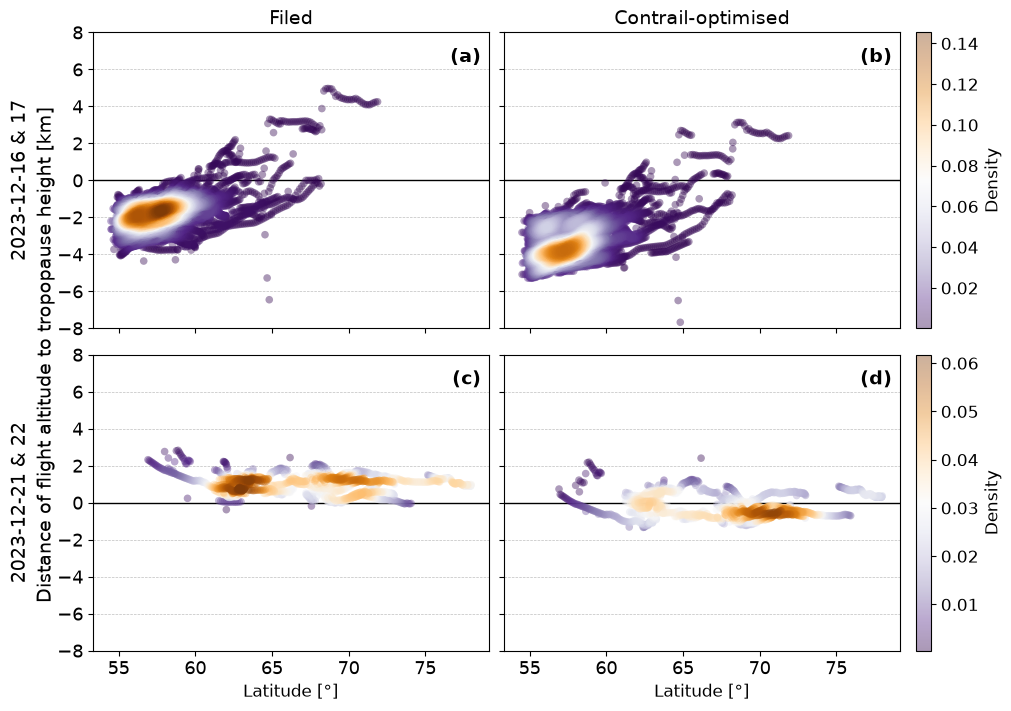

In [11]:
# delta fl to tropopause
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cane.labels import friendly_days
from matplotlib.ticker import FormatStrFormatter


def _compute_density(x, y):
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    return z


def _prep_for_plot(x, y, z):
    idx = z.argsort()
    return x[idx], y[idx], z[idx]


def plot_two_dfs(df1, df2):
    fig, ax = plt.subplots(nrows=2, ncols=2, sharey=True, figsize=(10, 7), constrained_layout=True, sharex=True)

    cmaps = ["PuOr_r", "PuOr_r"]

    for i, df in enumerate([df1, df2]):
        # compute again
        x = df.latitude.values
        y1 = df.distance_to_tropo_filed / 1e3
        y2 = df.distance_to_tropo_opt / 1e3

        z1 = _compute_density(x, y1)
        z2 = _compute_density(x, y2)

        vmin = min(z1.min(), z2.min())
        vmax = max(z1.max(), z2.max())

        # density plot 1
        xc1, yc1, zc1 = _prep_for_plot(x, y1, z1)
        sc1 = ax[i, 0].scatter(xc1, yc1, c=zc1, vmin=vmin, vmax=vmax,
                               cmap=cmaps[i], s=30, zorder=3,
                               marker="o", alpha=0.4, edgecolors='none')

        # density plot 2
        xc2, yc2, zc2 = _prep_for_plot(x, y2, z2)
        sc2 = ax[i, 1].scatter(xc2, yc2, c=zc2, vmin=vmin, vmax=vmax,
                               cmap=cmaps[i], s=30, zorder=3,
                               marker="o", alpha=0.4, edgecolors='none')

        for j in [0, 1]:
            # i, j ... row, col
            ax[i, j].grid(axis="y", color='gray', linewidth=0.5, alpha=0.5, linestyle='--')
            ax[i, j].axhline(0, color='black', linewidth=1)
            ax[i, j].set_ylim([-8, 8])
            ax[i, j].tick_params(labelsize=13)

        # ax[i, 0]

        cbar = fig.colorbar(sc2, ax=ax[i], location="right", fraction=0.05, pad=0.02)
        cbar.set_label("Density", fontsize=12)
        cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        cbar.ax.tick_params(labelsize=12)

    # ax[0, 0].grid(None)
    # ax[0, 1].grid(None)
    # ax[1, 0].grid(None)
    # ax[1, 1].grid(None)

    fig.text(
        0.03, 0.5, "Distance of flight altitude to tropopause height [km]",
        va="center", rotation="vertical", fontsize=14
    )

    ax[0, 0].set_ylabel(friendly_days[df1.day.unique()[0] - 1], labelpad=20, fontsize=14)
    ax[1, 0].set_ylabel(friendly_days[df2.day.unique()[0] - 1], labelpad=20, fontsize=14)

    ax[1, 0].set_xlabel("Latitude [$\degree$]", fontsize=12)
    ax[1, 1].set_xlabel("Latitude [$\degree$]", fontsize=12)

    ax[0, 0].set_title("Filed", fontsize=14)
    ax[0, 1].set_title("Contrail-optimised", fontsize=14)

    ax[0, 0].text(
        0.98, 0.95, "(a)",
        transform=ax[0, 0].transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax[0, 1].text(
        0.98, 0.95, "(b)",
        transform=ax[0, 1].transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax[1, 0].text(
        0.98, 0.95, "(c)",
        transform=ax[1, 0].transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )

    ax[1, 1].text(
        0.98, 0.95, "(d)",
        transform=ax[1, 1].transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="right"
    )


plot_two_dfs(
    df1=dfs[0],
    df2=dfs[1]
)

# plt.savefig("./figures/fig06.png", dpi=300, bbox_inches="tight")
plt.savefig(f"../figures/fig06_day{days}_{firs}.png", dpi=300, bbox_inches="tight")

In [12]:
print("if I filter for the is_excluded, results change drastically\n------------")

print("09/02 and 09/03 for ENOR, EKDK, ESAA:", 60 + 89 + 69, "flights traversing")
print("12/27 and 12/28 for ENOR, EKDK, ESAA:", 54 + 85 + 83, "flights traversing")

print("Emissions to climate:", [-8, -5, -5], "")
print("Emissions to climate:", [-6, 1, 0])

if I filter for the is_excluded, results change drastically
------------
09/02 and 09/03 for ENOR, EKDK, ESAA: 218 flights traversing
12/27 and 12/28 for ENOR, EKDK, ESAA: 222 flights traversing
Emissions to climate: [-8, -5, -5] 
Emissions to climate: [-6, 1, 0]


In [13]:
for i in range(8):
    print(round(dff.query("is_excluded == True and day == @i+1").flight_id.nunique() / dff.query(
        "day == @i+1").flight_id.nunique() * 100, 2))

30.77
8.41
5.11
0.34
7.94
14.32
17.79
22.83


In [14]:
firs = ["EFIN"]
print(dff.query("is_excluded == True and day == 7 and fir in @firs").flight_id.nunique())

29
